In [1]:
from util import *

directory = r'../../data/llm_evaluation/monetary/'

%matplotlib notebook

[nltk_data] Downloading package punkt to C:\Users\WK/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# resume work
df_test_stance = pd.read_excel(directory+'df_test_stance_mon_gpt.xlsx')
df_test_stance_a = pd.read_excel(directory+'df_test_stance_mon_0.xlsx')
df_test_stance_b = pd.read_excel(directory+'df_test_stance_mon_1.xlsx')
df_test_stance_c = pd.read_excel(directory+'df_test_stance_mon_2.xlsx')
df_test_stance_d = pd.read_excel(directory+'df_test_stance_mon_3.xlsx')
df_test_stance_a = pd.concat([df_test_stance_a, df_test_stance_b, df_test_stance_c, df_test_stance_d], ignore_index=True)
df_test_stance_b = pd.read_excel(directory+'df_train_stance_gpt.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance_a = df_test_stance_a.merge(df_test_stance_b)
df_test_stance = pd.concat([df_test_stance, df_test_stance_a], ignore_index=True)

df_test_stance2 = pd.read_excel(directory+'df_test_stance_mon_mistral.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2_a = pd.read_excel(directory+'df_train_stance_mistral.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2 = pd.concat([df_test_stance2, df_test_stance2_a], ignore_index=True)
df_test_stance = df_test_stance.merge(df_test_stance2)

df_test_stance2 = pd.read_excel(directory+'df_test_stance_llama.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2_a = pd.read_excel(directory+'df_train_stance_llama.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2 = pd.concat([df_test_stance2, df_test_stance2_a], ignore_index=True)
df_test_stance = df_test_stance.merge(df_test_stance2)

df_test_stance2 = pd.read_excel(directory+'df_test_stance_phi.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2_a = pd.read_excel(directory+'df_train_stance_phi.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2 = pd.concat([df_test_stance2, df_test_stance2_a], ignore_index=True)
df_test_stance = df_test_stance.merge(df_test_stance2)

df_test_stance2 = pd.read_excel(directory+'df_test_stance_gemma.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2_a = pd.read_excel(directory+'df_train_stance_gemma.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1)
df_test_stance2 = pd.concat([df_test_stance2, df_test_stance2_a], ignore_index=True)
df_test_stance = df_test_stance.merge(df_test_stance2)

df_test_agree = pd.read_excel(directory+'df_test_agree_mon_gpt.xlsx')
df_test_agree_a = pd.read_excel(directory+'df_test_agree_mon_0.xlsx')
df_test_agree_b = pd.read_excel(directory+'df_test_agree_mon_1.xlsx')
df_test_agree_c = pd.read_excel(directory+'df_test_agree_mon_2.xlsx')
df_test_agree_d = pd.read_excel(directory+'df_test_agree_mon_3.xlsx')
df_test_agree_a = pd.concat([df_test_agree_a, df_test_agree_b, df_test_agree_c, df_test_agree_d], ignore_index=True)
df_test_agree_b = pd.read_excel(directory+'df_train_agree_gpt.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree_a = df_test_agree_a.merge(df_test_agree_b)
df_test_agree = pd.concat([df_test_agree, df_test_agree_a], ignore_index=True)
df_test_agree = df_test_agree.drop(['agreement_gpt_ft', 'disagreement_areas_gpt_ft', 'reason_gpt_ft'], axis=1).rename(columns={c:c.replace('_ft4', '_ft') for c in df_test_agree.columns})

df_test_agree2 = pd.read_excel(directory+'df_test_agree_mon_mistral.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2_a = pd.read_excel(directory+'df_train_agree_mistral.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2 = pd.concat([df_test_agree2, df_test_agree2_a], ignore_index=True)
df_test_agree = df_test_agree.merge(df_test_agree2)

df_test_agree2 = pd.read_excel(directory+'df_test_agree_llama.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2_a = pd.read_excel(directory+'df_train_agree_llama.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2 = pd.concat([df_test_agree2, df_test_agree2_a], ignore_index=True)
df_test_agree = df_test_agree.merge(df_test_agree2)

df_test_agree2 = pd.read_excel(directory+'df_test_agree_phi.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2_a = pd.read_excel(directory+'df_train_agree_phi.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2 = pd.concat([df_test_agree2, df_test_agree2_a], ignore_index=True)
df_test_agree = df_test_agree.merge(df_test_agree2)

df_test_agree2 = pd.read_excel(directory+'df_test_agree_gemma.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2_a = pd.read_excel(directory+'df_train_agree_gemma.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree2 = pd.concat([df_test_agree2, df_test_agree2_a], ignore_index=True)
df_test_agree = df_test_agree.merge(df_test_agree2)


In [5]:
# add finetuned gpt-4o results
df_test_stance2a = pd.read_excel(directory+'gpt4o_ft/df_test_stance_mon.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1).rename(columns={c:c.replace('_ft', '_ft_4o') for c in ['stance_current_gpt_ft', 'stance_future_gpt_ft']})
df_test_stance2b = pd.read_excel(directory+'gpt4o_ft/df_test_stance_mon_0.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1).rename(columns={c:c.replace('_ft', '_ft_4o') for c in ['stance_current_gpt_ft', 'stance_future_gpt_ft']})
df_test_stance2c = pd.read_excel(directory+'gpt4o_ft/df_test_stance_mon_1.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1).rename(columns={c:c.replace('_ft', '_ft_4o') for c in ['stance_current_gpt_ft', 'stance_future_gpt_ft']})
df_test_stance2d = pd.read_excel(directory+'gpt4o_ft/df_test_stance_mon_2.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1).rename(columns={c:c.replace('_ft', '_ft_4o') for c in ['stance_current_gpt_ft', 'stance_future_gpt_ft']})
df_test_stance2e = pd.read_excel(directory+'gpt4o_ft/df_test_stance_mon_3.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_current', 'stance_future'], axis=1).rename(columns={c:c.replace('_ft', '_ft_4o') for c in ['stance_current_gpt_ft', 'stance_future_gpt_ft']})
df_test_stance2 = pd.concat([df_test_stance2a, df_test_stance2b, df_test_stance2c, df_test_stance2d, df_test_stance2e], ignore_index=True)

df_test_stance = df_test_stance.merge(df_test_stance2)

In [6]:
model_l = ['gpt1', 'gpt5', 'gpt6', 'gemma', 'llama3-8b-instruct', 'mistral7b', 'phi', 'gpt2', 'gpt3', 'gpt4', 'gpt_ft', 'gpt_ft_4o']
key_columns = ['stance_current', 'stance_future']
key_columns_agree = ['agreement', 'agreement_general', 'disagreement_areas', 'disagreement_areas_general']

for i, row in df_test_agree.iterrows():
    for ty in ['staff', 'buff']:
        for col in key_columns:
            df_test_agree.loc[i, ty+'_'+col] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][col]
            for model in model_l:
                var = col + '_' + model
                df_test_agree.loc[i, ty+'_'+var] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][var]

# agreement general
df_test_agree['agreement'] = df_test_agree['agreement_general']
df_test_agree['agreement_stance_current'] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_current'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_current']!=x['staff_stance_current'] or x['buff_stance_current'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_current'] else 'mostly agree' if x['staff_stance_current']==x['buff_stance_current'] else 'disagreement exists', axis=1)
df_test_agree['agreement_stance_future'] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_future'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_future']!=x['staff_stance_future'] or x['buff_stance_future'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_future']!=x['buff_stance_future'] else 'mostly agree' if x['staff_stance_future']==x['buff_stance_future'] else 'disagreement exists', axis=1)
df_test_agree['disagreement_areas_general'] = df_test_agree['disagreement_areas']

for model in model_l:
    if model != 'gpt_ft_4o':
        df_test_agree['agreement_stance_current'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_current'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_current'+'_'+model]!=x['staff_stance_current'+'_'+model] or x['buff_stance_current'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_current'+'_'+model] else 'mostly agree' if x['staff_stance_current'+'_'+model]==x['buff_stance_current'+'_'+model] else 'disagreement exists', axis=1)
        df_test_agree['agreement_stance_future'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_future'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_future'+'_'+model]!=x['staff_stance_future'+'_'+model] or x['buff_stance_future'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_future'+'_'+model]!=x['buff_stance_future'+'_'+model] else 'mostly agree' if x['staff_stance_future'+'_'+model]==x['buff_stance_future'+'_'+model] else 'disagreement exists', axis=1)
        df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree['disagreement_areas'+'_'+model].fillna('')
        df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree.apply(lambda x: (x['disagreement_areas_general'+'_'+model]+'; Current Policy Stance').strip('; ') if x['agreement_stance_current'+'_'+model]=='disagreement exists' else x['disagreement_areas_general'+'_'+model], axis=1)
        df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree.apply(lambda x: (x['disagreement_areas_general'+'_'+model]+'; Future Policy Stance').strip('; ') if x['agreement_stance_future'+'_'+model]=='disagreement exists' else x['disagreement_areas_general'+'_'+model], axis=1)
        # df_test_agree['agreement_general'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['agreement_stance_current'+'_'+model]=='irrelevant' and x['agreement_stance_future'+'_'+model]=='irrelevant' and (x['agreement'+'_'+model] in ['', 'n', 'nan', 'irrelevant'] or x['agreement'+'_'+model]!=x['agreement'+'_'+model]) else 'disagreement exists' if x['agreement_stance_current'+'_'+model]=='disagreement exists' or x['agreement_stance_future'+'_'+model]=='disagreement exists' or x['agreement'+'_'+model]=='disagreement exists' else 'mostly agree', axis=1)
        df_test_agree['agreement_general'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['agreement_stance_future'+'_'+model]=='irrelevant' and (x['agreement'+'_'+model] in ['', 'n', 'nan', 'irrelevant'] or x['agreement'+'_'+model]!=x['agreement'+'_'+model]) else 'disagreement exists' if x['agreement_stance_future'+'_'+model]=='disagreement exists' or x['agreement'+'_'+model]=='disagreement exists' else 'mostly agree', axis=1)

# disagreement areas dummy
for c in df_test_agree.columns:
    if 'disagreement_areas' in c:
        df_test_agree[c] = df_test_agree[c].apply(lambda x: x.replace('Future Policy Stance', 'Future Policy Direction') if x==x else x)

da_vals = list(set(itertools.chain.from_iterable(df_test_agree['disagreement_areas'].apply(lambda x: x.split('; ') if x==x else []))))

for model in model_l:
    if model != 'gpt_ft_4o':
        for val in da_vals:
            for col in ['disagreement_areas', 'disagreement_areas_general']:
                df_test_agree[col+'_'+val] = df_test_agree[col].apply(lambda x: x==x and val in x)
                df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)

C:\Users\WK\AppData\Local\Temp\ipykernel_19224\3926354204.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree['agreement_stance_current'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_current'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_current'+'_'+model]!=x['staff_stance_current'+'_'+model] or x['buff_stance_current'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_current'+'_'+model] else 'mostly agree' if x['staff_stance_current'+'_'+model]==x['buff_stance_current'+'_'+model] else 'disagreement exists', axis=1)
C:\Users\WK\AppData\Local\Temp\ipykernel_19224\3926354204.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

C:\Users\WK\AppData\Local\Temp\ipykernel_19224\3926354204.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)
C:\Users\WK\AppData\Local\Temp\ipykernel_19224\3926354204.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)
C:\Users\WK\AppData\Local\Temp\ipykernel_19224\3926354204.py:41: PerformanceWarning: DataFrame is highly f

In [7]:
for model in model_l:
    for col in key_columns:
        print(df_test_stance[col+'_'+model].isna().value_counts())

stance_current_gpt1
False    578
Name: count, dtype: int64
stance_future_gpt1
False    578
Name: count, dtype: int64
stance_current_gpt5
False    578
Name: count, dtype: int64
stance_future_gpt5
False    578
Name: count, dtype: int64
stance_current_gpt6
False    578
Name: count, dtype: int64
stance_future_gpt6
False    578
Name: count, dtype: int64
stance_current_gemma
False    569
True       9
Name: count, dtype: int64
stance_future_gemma
False    569
True       9
Name: count, dtype: int64
stance_current_llama3-8b-instruct
False    578
Name: count, dtype: int64
stance_future_llama3-8b-instruct
False    578
Name: count, dtype: int64
stance_current_mistral7b
False    578
Name: count, dtype: int64
stance_future_mistral7b
False    578
Name: count, dtype: int64
stance_current_phi
False    578
Name: count, dtype: int64
stance_future_phi
False    578
Name: count, dtype: int64
stance_current_gpt2
False    578
Name: count, dtype: int64
stance_future_gpt2
False    578
Name: count, dtype: int64


In [150]:
for model in model_l:
    if model != 'gpt_ft_4o':
        for col in ['agreement']:
            print(df_test_agree[col+'_'+model].isna().value_counts())

agreement_gpt1
False    289
Name: count, dtype: int64
agreement_gpt5
False    289
Name: count, dtype: int64
agreement_gpt6
False    289
Name: count, dtype: int64
agreement_gemma
False    214
True      75
Name: count, dtype: int64
agreement_llama3-8b-instruct
False    289
Name: count, dtype: int64
agreement_mistral7b
False    289
Name: count, dtype: int64
agreement_phi
False    289
Name: count, dtype: int64
agreement_gpt2
False    289
Name: count, dtype: int64
agreement_gpt3
False    289
Name: count, dtype: int64
agreement_gpt4
False    289
Name: count, dtype: int64
agreement_gpt_ft
False    289
Name: count, dtype: int64


In [9]:
results_l = []
for col in key_columns:
    for model in model_l:
        results_l.append(evaluate(df_test_stance, model, col, stance=True))
for col in key_columns_agree:
    for model in model_l:
        if model != 'gpt_ft_4o':
            results_l.append(evaluate(df_test_agree, model, col))

df_result = pd.DataFrame(results_l)
df_result['name'] = df_result['name'].apply(lambda x: x.replace('gpt1', 'gpt-4o').replace('gpt2', 'gpt-4o_long_prompt').replace('gpt3', 'gpt-4o_cot').replace('gpt4','gpt-4o_few_shot').replace('gpt5','gpt-4o-mini').replace('gpt6','gpt-3.5-turbo').replace('gpt_ft_4o','gpt-4o_finetuned').replace('gpt_ft','gpt-4o-mini_finetuned').replace('mistral7b','mistral-7b-instruct').replace('phi', 'phi-3-small-128k-instruct').replace('gemma', 'gemma-2-9b-it'))


In [164]:
df_result.to_excel(directory+'df_result_monetary.xlsx', index=False)

In [10]:
group1 = ['gpt-4o', 'gpt-4o_long_prompt', 'gpt-4o_cot']
group2 = ['gpt-4o', 'gpt-4o-mini', 'gpt-4o_few_shot', 'gpt-4o-mini_finetuned', 'gpt-4o_finetuned']
group3 = ['gpt-4o',
 'gpt-4o-mini',
 'gpt-3.5-turbo', 'gemma-2-9b-it',
 'llama3-8b-instruct',
 'mistral-7b-instruct',
 'phi-3-small-128k-instruct']

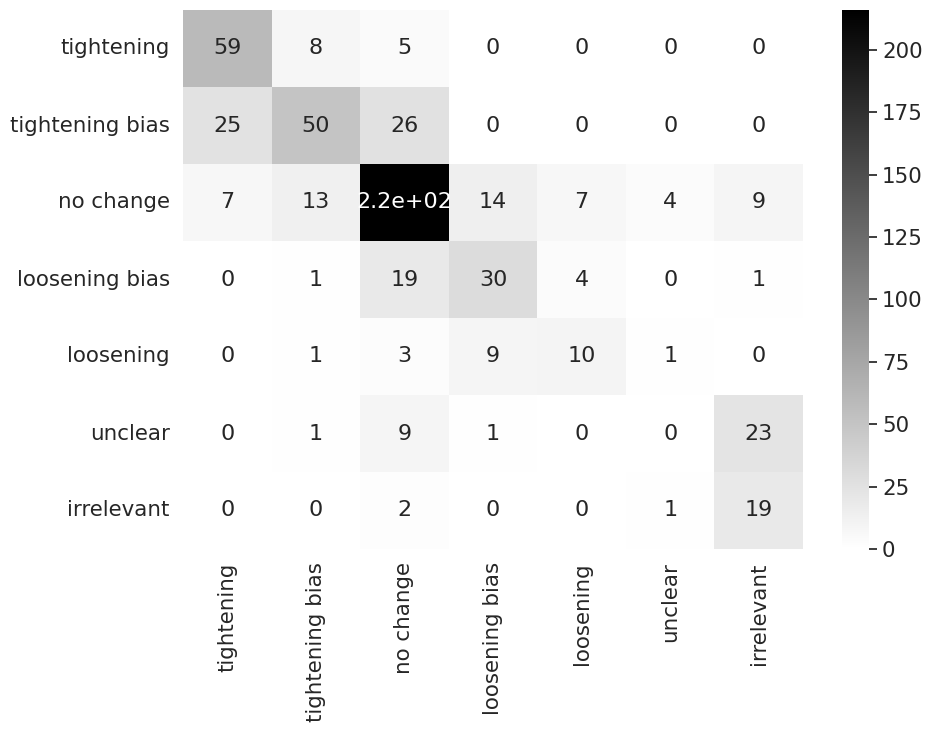

In [178]:
labels = ['tightening', 'tightening bias', 'no change', 'loosening bias', 'loosening', 'unclear', 'irrelevant']
cm = confusion_matrix(df_test_stance['stance_future'], df_test_stance['stance_future_gpt1'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.show()

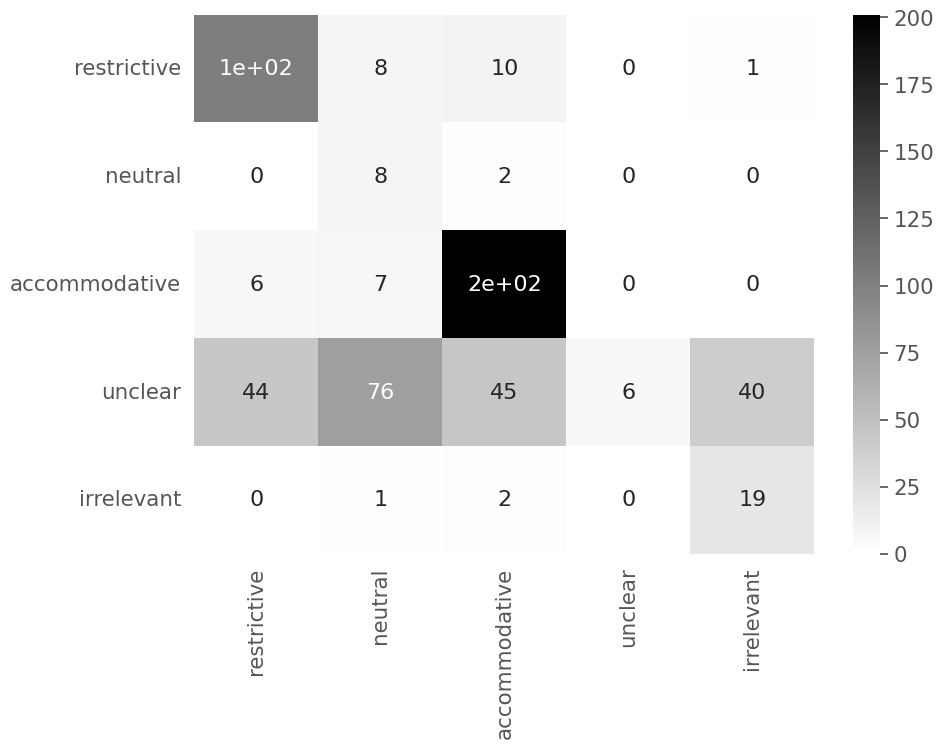

In [174]:
labels = ['restrictive', 'neutral', 'accommodative', 'unclear', 'irrelevant']
cm = confusion_matrix(df_test_stance['stance_current'], df_test_stance['stance_current_gpt1'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.show()

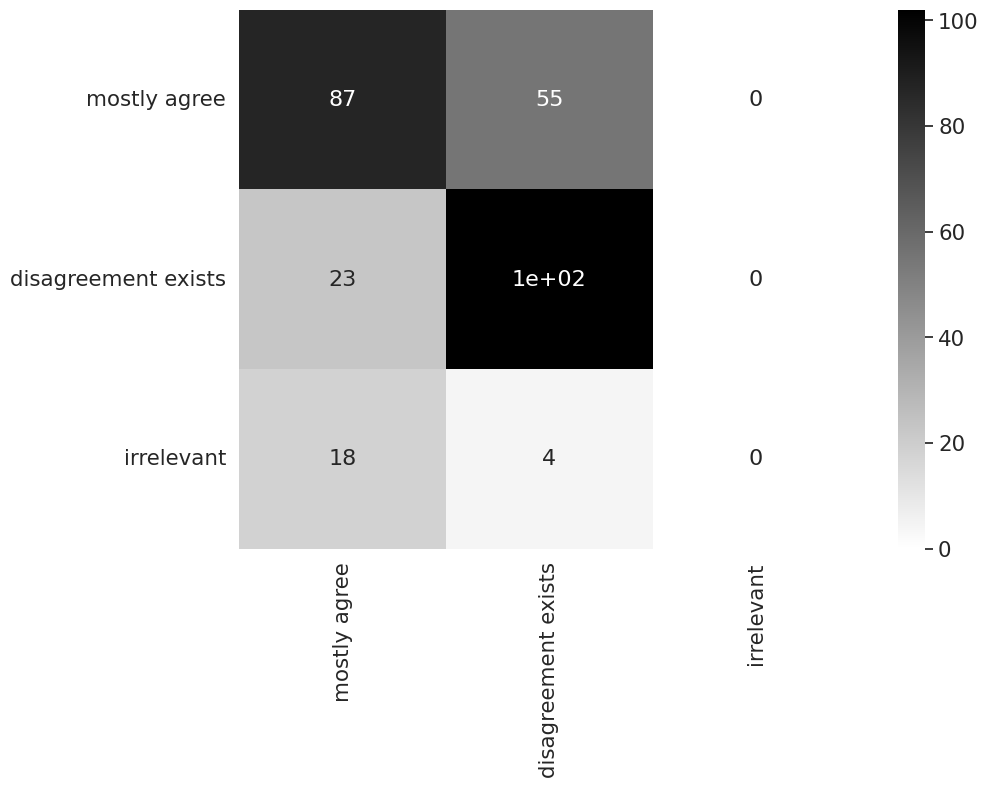

In [180]:
labels = ['mostly agree', 'disagreement exists', 'irrelevant']
cm = confusion_matrix(df_test_agree['agreement_general'], df_test_agree['agreement_general_gpt5'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xticks([0.5,1.5,2.5], labels, rotation='vertical')
plt.yticks([0.5,1.5,2.5], labels, rotation='horizontal')
plt.show()

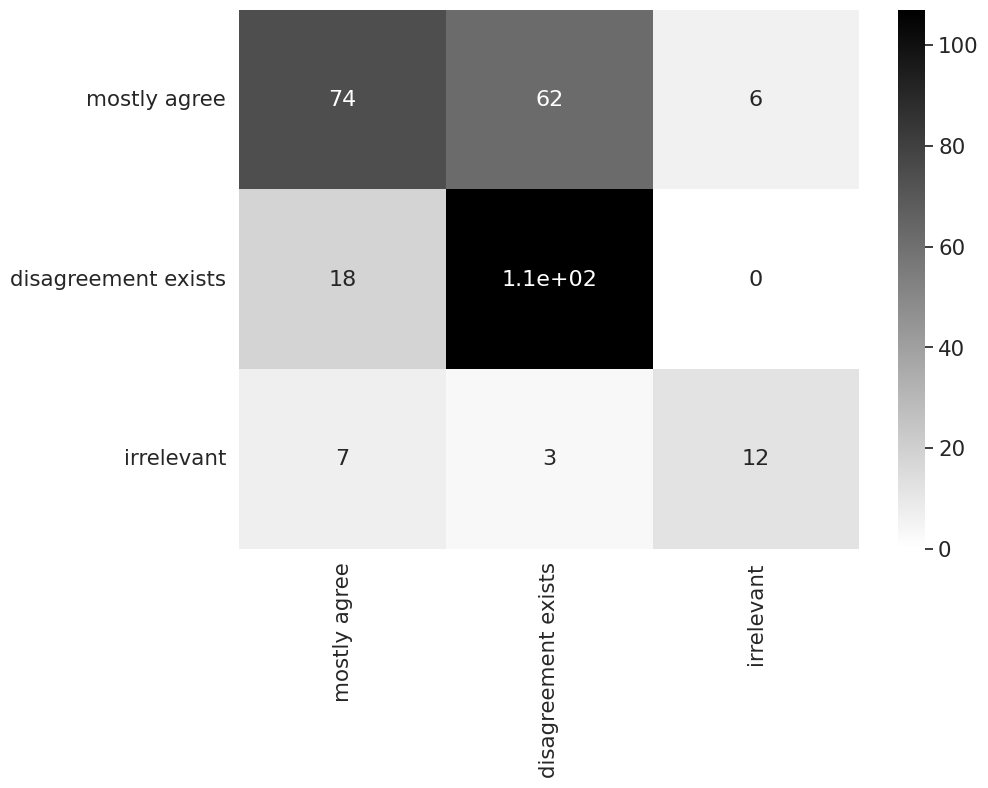

In [181]:
labels = ['mostly agree', 'disagreement exists', 'irrelevant']
cm = confusion_matrix(df_test_agree['agreement_general'], df_test_agree['agreement_general_gpt_ft'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xticks([0.5,1.5,2.5], labels, rotation='vertical')
plt.yticks([0.5,1.5,2.5], labels, rotation='horizontal')
plt.show()

In [ ]:
df_test_agree[(df_test_agree['agreement_stance_future']=='mostly agree')&(df_test_agree['agreement_stance_future_gpt_ft']=='disagreement exists')][['staff_stance_future', 'buff_stance_future', 'staff_stance_future_gpt_ft', 'buff_stance_future_gpt_ft']].value_counts().sort_index()

staff_stance_future  buff_stance_future  staff_stance_future_gpt_ft  buff_stance_future_gpt_ft
loosening            loosening           loosening                   no change                    1
                                         loosening bias              loosening                    1
                                         no change                   loosening bias               1
loosening bias       loosening bias      loosening                   no change                    1
                                         loosening bias              loosening                    1
                                                                     no change                    2
                                                                     tightening bias              1
                                         no change                   loosening bias               1
no change            no change           loosening bias              loosening                    1
                                                                     no change                    4
                                         no change                   loosen                       1
                                                                     loosening                    1
                                                                     loosening bias               5
                                                                     tightening bias              2
                                         tightening                  no change                    2
                                         tightening bias             no change                    2
tightening           tightening          tightening                  no change                    1
                                                                     tightening bias              6
tightening bias      tightening bias     no change                   tightening                   1
                                                                     tightening bias              1
                                         tightening                  no change                    1
                                                                     tightening bias              2
                                         tightening bias             no change                    7
                                                                     tightening                   3
Name: count, dtype: int64

In [173]:
plt.rcParams['figure.figsize'] = (10,7)

In [ ]:
df_result[(df_result['variable']=='stance_current')&(df_result['name'].apply(lambda x: x in group1))].drop('recall', axis=1)

,name,variable,accuracy,f1_score,accuracy_m,f1_score_m,f1_score_e
0,gpt-4o,stance_current,0.581315,0.510777,0.650519,0.648218,0.792365
7,gpt-4o_long_prompt,stance_current,0.576125,0.514958,0.608997,0.591222,0.788395
8,gpt-4o_cot,stance_current,0.589965,0.532477,0.652249,0.650613,0.798328


In [12]:
df_temp = df_result[(df_result['variable']=='stance_future')].drop(['accuracy', 'f1_score','recall', 'f1_score_e'], axis=1)
df_temp

,name,variable,accuracy_m,f1_score_m
12,gpt-4o,stance_future,0.785467,0.785564
13,gpt-4o-mini,stance_future,0.776817,0.771616
14,gpt-3.5-turbo,stance_future,0.723183,0.704675
15,gemma-2-9b-it,stance_future,0.567474,0.566561
16,llama3-8b-instruct,stance_future,0.621107,0.651273
17,mistral-7b-instruct,stance_future,0.442907,0.490631
18,phi-3-small-128k-instruct,stance_future,0.638408,0.647475
19,gpt-4o_long_prompt,stance_future,0.761246,0.760013
20,gpt-4o_cot,stance_future,0.788927,0.789125
21,gpt-4o_few_shot,stance_future,0.794118,0.794637


<IPython.core.display.Javascript object>


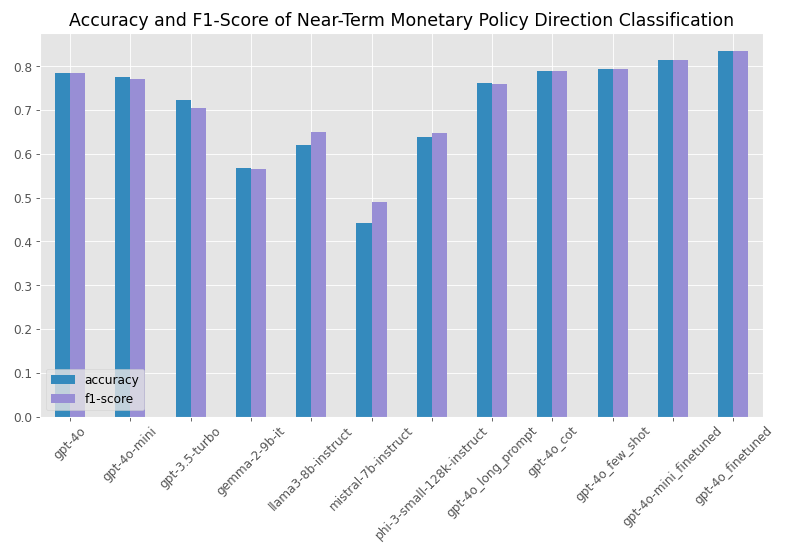

In [44]:
df_temp.set_index('name')[['accuracy_m', 'f1_score_m']].plot.bar(color=colors[1:])
plt.title('Accuracy and F1-Score of Near-Term Monetary Policy Direction Classification')
plt.legend(['accuracy', 'f1-score'], loc='lower left')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()

In [170]:
df_temp = df_result[(df_result['variable']=='agreement_general')&(df_result['name'].apply(lambda x: x in group2))].drop(['accuracy', 'f1_score', 'f1_score_e'], axis=1)
df_temp

,name,variable,accuracy_m,f1_score_m,recall
35,gpt-4o,agreement_general,0.730104,0.730227,0.840
36,gpt-4o-mini,agreement_general,0.716263,0.716630,0.816
44,gpt-4o_few_shot,agreement_general,0.723183,0.723309,0.832
45,gpt-4o-mini_finetuned,agreement_general,0.712803,0.711509,0.856


Text(0.5, 0, '')

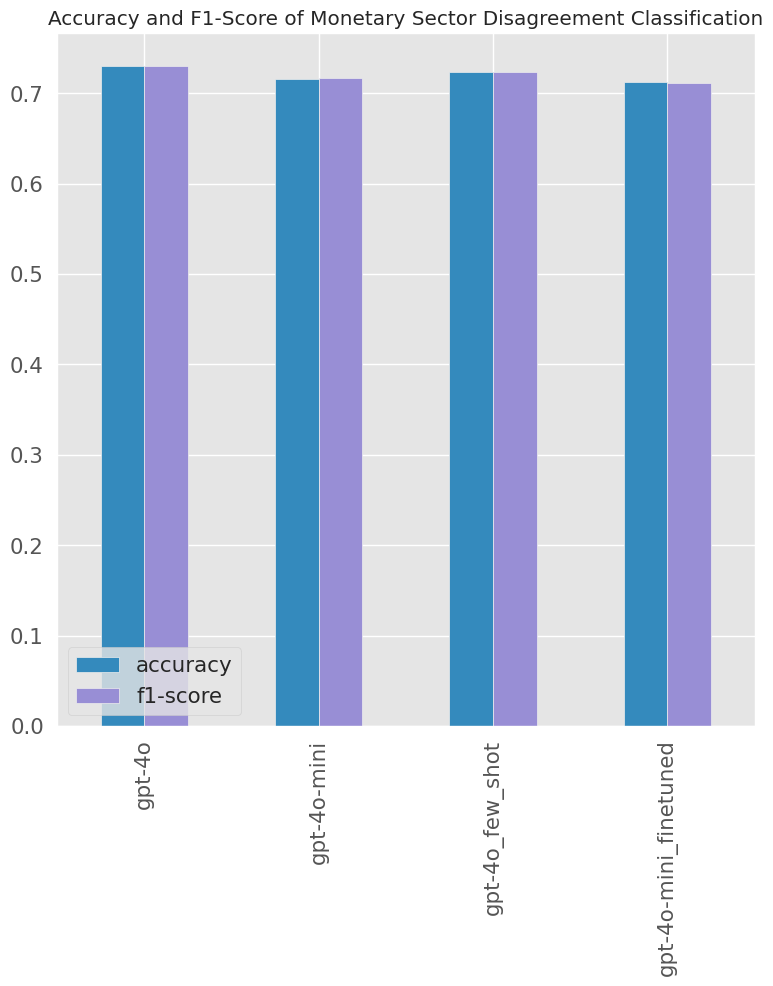

In [171]:
df_temp.set_index('name')[['accuracy_m','f1_score_m']].plot.bar(color=colors[1:])
# df_temp.set_index('name')[].plot.bar(color=colors[2])
plt.title('Accuracy and F1-Score of Monetary Sector Disagreement Classification')
plt.legend(['accuracy', 'f1-score'], loc='lower left')
plt.xlabel('')

In [ ]:
df_result[(df_result['variable']=='disagreement_areas_general')&(df_result['name'].apply(lambda x: x in group2))].drop(['accuracy_m', 'f1_score_m', 'f1_score_e'], axis=1)

,name,variable,accuracy,f1_score,recall
55,gpt-4o,disagreement_areas_general,0.532872,0.584924,0.737931
56,gpt-4o-mini,disagreement_areas_general,0.536332,0.529791,0.696552
64,gpt-4o_few_shot,disagreement_areas_general,0.581315,0.571213,0.710345
65,gpt-4o-mini_finetuned,disagreement_areas_general,0.619377,0.528459,0.655172


In [ ]:
df_result[(df_result['variable']=='agreement_general')].drop('f1_score_e', axis=1)

,name,variable,accuracy,f1_score,accuracy_m,f1_score_m,recall
33,gpt-4o,agreement_general,0.671280,0.649480,0.730104,0.730227,0.840
34,gpt-4o-mini,agreement_general,0.653979,0.625162,0.716263,0.716630,0.816
35,gpt-3.5-turbo,agreement_general,0.584775,0.561444,0.643599,0.644334,0.608
36,gemma-2-9b-it,agreement_general,0.470588,0.423888,0.512111,0.479821,0.816
37,llama3-8b-instruct,agreement_general,0.560554,0.537140,0.595156,0.595156,0.688
38,mistral-7b-instruct,agreement_general,0.591696,0.567578,0.650519,0.650348,0.592
39,phi-3-small-128k-instruct,agreement_general,0.501730,0.477996,0.536332,0.533932,0.656
40,gpt-4o_long_prompt,agreement_general,0.657439,0.640299,0.698962,0.698666,0.816
41,gpt-4o_cot,agreement_general,0.657439,0.637188,0.709343,0.709718,0.808
42,gpt-4o_few_shot,agreement_general,0.678201,0.665649,0.723183,0.723309,0.832


In [83]:
df_result[(df_result['variable']=='disagreement_areas')].drop(['accuracy_m', 'f1_score_m', 'f1_score_e'], axis=1)

,name,variable,accuracy,f1_score,recall
44,gpt-4o,disagreement_areas,0.539792,0.406369,0.358621
45,gpt-4o-mini,disagreement_areas,0.480969,0.337665,0.331034
46,gpt-3.5-turbo,disagreement_areas,0.487889,0.159754,0.131034
47,gemma-2-9b-it,disagreement_areas,0.363322,0.333779,0.351724
48,llama3-8b-instruct,disagreement_areas,0.408304,0.318473,0.324138
49,mistral-7b-instruct,disagreement_areas,0.442907,0.381745,0.420690
50,phi-3-small-128k-instruct,disagreement_areas,0.567474,0.000000,0.000000
51,gpt-4o_long_prompt,disagreement_areas,0.550173,0.430179,0.386207
52,gpt-4o_cot,disagreement_areas,0.536332,0.371049,0.331034
53,gpt-4o_few_shot,disagreement_areas,0.560554,0.350388,0.296552


In [ ]:
# df_test_stance[df_test_stance['type']=='buff']['stance_current'].value_counts().sort_index().plot.pie()
# plt.title('current stance - authorities')
# plt.ylabel('')

pd.DataFrame([i for i in '; '.join(df_test_agree['disagreement_areas'].fillna('')).split('; ') if i != ''])[0].value_counts().plot.pie()
plt.title('disagreement_areas')
plt.ylabel('')

In [ ]:
df_test_agree['text_len'] = df_test_agree['staff'].apply(lambda x: len(x))+df_test_agree['buff'].apply(lambda x: len(x))

<ipython-input-104-7f2d89efc12f>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree['text_len'] = df_test_agree['staff'].apply(lambda x: len(x))+df_test_agree['buff'].apply(lambda x: len(x))


In [61]:
# combine the results from fiscal
directory = r'../../data/llm_evaluation/fiscal/'

df_test_stance_e = pd.read_excel(directory+'df_test_stance_fis_4_v1.xlsx')
df_test_stance_a = pd.read_excel(directory+'df_test_stance_fis_0_v1.xlsx')
df_test_stance_b = pd.read_excel(directory+'df_test_stance_fis_1_v1.xlsx')
df_test_stance_c = pd.read_excel(directory+'df_test_stance_fis_2_v1.xlsx')
df_test_stance_d = pd.read_excel(directory+'df_test_stance_fis_3_v1.xlsx')
df_test_stance = pd.concat([df_test_stance_e, df_test_stance_a, df_test_stance_b, df_test_stance_c, df_test_stance_d], ignore_index=True)

df_test_agree_e = pd.read_excel(directory+'df_test_agree_fis_4.xlsx')
df_test_agree_a = pd.read_excel(directory+'df_test_agree_fis_0.xlsx')
df_test_agree_b = pd.read_excel(directory+'df_test_agree_fis_1.xlsx')
df_test_agree_c = pd.read_excel(directory+'df_test_agree_fis_2.xlsx')
df_test_agree_d = pd.read_excel(directory+'df_test_agree_fis_3.xlsx')
df_test_agree = pd.concat([df_test_agree_a, df_test_agree_b, df_test_agree_c, df_test_agree_d, df_test_agree_e], ignore_index=True)

In [62]:
df_test_agree.drop(['disagreement_areas_government debt & financing',
       'disagreement_areas_government debt & financing_gpt_ft',
       'disagreement_areas_government revenue',
       'disagreement_areas_government revenue_gpt_ft',
       'disagreement_areas_near-term policy direction',
       'disagreement_areas_near-term policy direction_gpt_ft',
       'disagreement_areas_government expenditure',
       'disagreement_areas_government expenditure_gpt_ft',
       'disagreement_areas_economic fundamentals',
       'disagreement_areas_economic fundamentals_gpt_ft',
       'disagreement_areas_fiscal framework',
       'disagreement_areas_fiscal framework_gpt_ft',
       'disagreement_areas_public sector borrowing',
       'disagreement_areas_public sector borrowing_gpt_ft',
       'disagreement_areas_medium-term fiscal stance',
       'disagreement_areas_medium-term fiscal stance_gpt_ft',
       'disagreement_areas_fiscal multiplier estimation',
       'disagreement_areas_fiscal multiplier estimation_gpt_ft',
       'disagreement_areas_political cycle',
       'disagreement_areas_political cycle_gpt_ft'], axis=1, inplace=True)

In [63]:
model_l = ['gpt_ft']
key_columns = ['stance_near_term']
key_columns_agree = ['agreement', 'agreement_general', 'disagreement_areas', 'disagreement_areas_general']

for i, row in df_test_agree.iterrows():
    for ty in ['staff', 'buff']:
        for col in key_columns:
            df_test_agree.loc[i, ty+'_'+col] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][col]
            for model in model_l:
                var = col + '_' + model
                df_test_agree.loc[i, ty+'_'+var] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][var]

# agreement general
df_test_agree['agreement'] = df_test_agree['agreement_general']
df_test_agree['agreement_stance_near_term'] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_near_term'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_near_term']!=x['staff_stance_near_term'] or x['buff_stance_near_term'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_near_term']!=x['buff_stance_near_term'] else 'mostly agree' if x['staff_stance_near_term']==x['buff_stance_near_term'] else 'disagreement exists', axis=1)
df_test_agree['disagreement_areas_general'] = df_test_agree['disagreement_areas']

for model in model_l:
    df_test_agree['agreement_stance_near_term'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_near_term'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_near_term'+'_'+model]!=x['staff_stance_near_term'+'_'+model] or x['buff_stance_near_term'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_near_term'+'_'+model]!=x['buff_stance_near_term'+'_'+model] else 'mostly agree' if x['staff_stance_near_term'+'_'+model]==x['buff_stance_near_term'+'_'+model] else 'disagreement exists', axis=1)
    df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree['disagreement_areas'+'_'+model].fillna('')
    df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree.apply(lambda x: (x['disagreement_areas_general'+'_'+model]+'; near-term policy direction').strip('; ') if x['agreement_stance_near_term'+'_'+model]=='disagreement exists' else x['disagreement_areas_general'+'_'+model], axis=1)
    df_test_agree['agreement_general'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['agreement_stance_near_term'+'_'+model]=='irrelevant' and (x['agreement'+'_'+model] in ['', 'n', 'nan', 'irrelevant'] or x['agreement'+'_'+model]!=x['agreement'+'_'+model]) else 'disagreement exists' if x['agreement_stance_near_term'+'_'+model]=='disagreement exists' or x['agreement'+'_'+model]=='disagreement exists' else 'mostly agree', axis=1)

# disagreement areas dummy
for c in df_test_agree.columns:
    if 'disagreement_areas' in c:
        df_test_agree[c] = df_test_agree[c].apply(lambda x: x.replace('Future Policy Stance', 'Future Policy Direction') if x==x else x)

da_vals = list(set(itertools.chain.from_iterable(df_test_agree['disagreement_areas'].apply(lambda x: x.split('; ') if x==x else []))))

for model in model_l:
    for val in da_vals:
        for col in ['disagreement_areas', 'disagreement_areas_general']:
            df_test_agree[col+'_'+val] = df_test_agree[col].apply(lambda x: x==x and val in x)
            df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)

In [64]:
results_l = []
for col in key_columns:
    for model in model_l:
        results_l.append(evaluate(df_test_stance, model, col, stance=True))
for col in key_columns_agree:
    for model in model_l:
        results_l.append(evaluate(df_test_agree, model, col))

df_result_fis = pd.DataFrame(results_l)
df_result_fis['name'] = df_result_fis['name'].apply(lambda x: x.replace('gpt1', 'gpt-4o').replace('gpt2', 'gpt-4o_long_prompt').replace('gpt3', 'gpt-4o_cot').replace('gpt4','gpt-4o_few_shot').replace('gpt5','gpt-4o-mini').replace('gpt6','gpt-3.5-turbo').replace('gpt_ft','gpt-4o-mini_finetuned').replace('mistral7b','mistral-7b-instruct').replace('phi', 'phi-3-small-128k-instruct').replace('gemma', 'gemma-2-9b-it'))


C:\Users\WK\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
df_result_fis['variable'] = df_result_fis['variable'].apply(lambda x: 'fis_'+x)
df_result['variable'] = df_result['variable'].apply(lambda x: 'mon_'+x)
df_result = pd.concat([df_result, df_result_fis], ignore_index=True)

In [71]:
df_temp = df_result[df_result['name']=='gpt-4o-mini_finetuned']
df_temp

,name,variable,accuracy,f1_score,accuracy_m,f1_score_m,f1_score_e,recall
10,gpt-4o-mini_finetuned,mon_stance_current,0.809689,0.808369,0.835640,0.836349,0.853911,NaN
22,gpt-4o-mini_finetuned,mon_stance_future,0.702422,0.699219,0.814879,0.815661,0.706536,NaN
34,gpt-4o-mini_finetuned,mon_agreement,0.657439,0.656687,0.702422,0.700625,NaN,0.616000
45,gpt-4o-mini_finetuned,mon_agreement_general,0.667820,0.659068,0.712803,0.711509,NaN,0.856000
56,gpt-4o-mini_finetuned,mon_disagreement_areas,0.626298,0.472476,NaN,NaN,NaN,0.462069
67,gpt-4o-mini_finetuned,mon_disagreement_areas_general,0.619377,0.528459,NaN,NaN,NaN,0.655172
68,gpt-4o-mini_finetuned,fis_stance_near_term,0.705000,0.682104,0.800000,0.795898,0.000000,NaN
69,gpt-4o-mini_finetuned,fis_agreement,0.696667,0.660366,0.796667,0.794728,NaN,0.660000
70,gpt-4o-mini_finetuned,fis_agreement_general,0.683333,0.650126,0.763333,0.769069,NaN,0.790000
71,gpt-4o-mini_finetuned,fis_disagreement_areas,0.680000,0.422123,NaN,NaN,NaN,0.388889


<IPython.core.display.Javascript object>


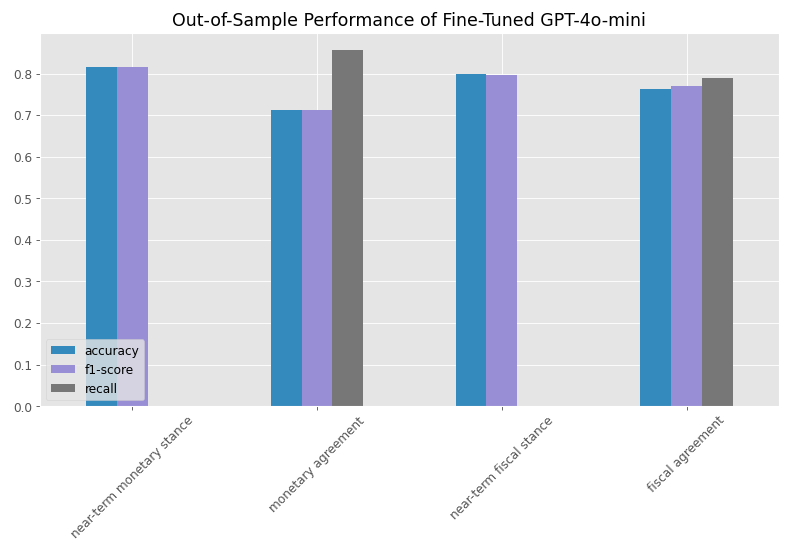

In [76]:
df_temp[df_temp['variable'].apply(lambda x: 'future' in x or 'near_term' in x or 'agreement_general' in x)][['accuracy_m', 'f1_score_m', 'recall']].plot.bar(color=colors[1:])
plt.title('Out-of-Sample Performance of Fine-Tuned GPT-4o-mini')
plt.legend(['accuracy', 'f1-score', 'recall'], loc='lower left')
plt.xlabel('')
plt.xticks(range(4), ['near-term monetary stance', 'monetary agreement', 'near-term fiscal stance', 'fiscal agreement'], rotation=45)
plt.tight_layout()